In [18]:
from google.colab import files
uploaded = files.upload()


Saving Pedidos de Compras.csv to Pedidos de Compras (2).csv


In [21]:
import pandas as pd
df = pd.read_csv('Pedidos de Compras (2).csv')
df. head()

,Timestamp,Setor Requisitante.,Centro de Custo.,Tipo do pedido.,Descrição do item 3 - Com todas as especificações detalhadas com quantidades.,Marca/Modelo.,Você precisa de uma amostra? Precisa fazer alguma observação? Deixe aqui comentários diversos que ache necessário para a compra do pedido.,Data da necessidade:
0,2/21/2025 14:44:09,Marketing,Marketing,Material.,NaN,NaN,preciso de amostra fisica,3/11/2025
1,2/21/2025 15:37:02,At-Home,At-Home,Material.,NaN,Mondial,NaN,2/21/2025
2,2/21/2025 15:43:57,Marketing,Prefeitura,Material.,NaN,NaN,Preciso ver uma prova antes da produção dos ba...,3/6/2025
3,2/24/2025 15:25:36,Marketing,Marketing,Material.,NaN,NaN,sim,2/27/2025
4,2/25/2025 10:01:32,Administrativo,Administrativo,Material.,NaN,oi,oi,3/1/2025


In [22]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 8 columns):
 #   Column                                                                                                                                      Non-Null Count  Dtype 
---  ------                                                                                                                                      --------------  ----- 
 0   Timestamp                                                                                                                                   72 non-null     object
 1   Setor Requisitante.                                                                                                                         72 non-null     object
 2   Centro de Custo.                                                                                                                            72 non-null     object
 3   Tipo do pedido.                                      

Index(['Timestamp', 'Setor Requisitante.', 'Centro de Custo.',
       'Tipo do pedido.',
       'Descrição do item 3 -  Com todas as especificações detalhadas com quantidades.',
       'Marca/Modelo.',
       'Você precisa de uma amostra? Precisa fazer alguma observação? Deixe aqui comentários diversos que ache necessário para a compra do pedido.',
       'Data da necessidade:'],
      dtype='object')

In [23]:
import pandas as pd
df = pd.read_csv('Pedidos de Compras (2).csv')
df.head()

,Timestamp,Setor Requisitante.,Centro de Custo.,Tipo do pedido.,Descrição do item 3 - Com todas as especificações detalhadas com quantidades.,Marca/Modelo.,Você precisa de uma amostra? Precisa fazer alguma observação? Deixe aqui comentários diversos que ache necessário para a compra do pedido.,Data da necessidade:
0,2/21/2025 14:44:09,Marketing,Marketing,Material.,NaN,NaN,preciso de amostra fisica,3/11/2025
1,2/21/2025 15:37:02,At-Home,At-Home,Material.,NaN,Mondial,NaN,2/21/2025
2,2/21/2025 15:43:57,Marketing,Prefeitura,Material.,NaN,NaN,Preciso ver uma prova antes da produção dos ba...,3/6/2025
3,2/24/2025 15:25:36,Marketing,Marketing,Material.,NaN,NaN,sim,2/27/2025
4,2/25/2025 10:01:32,Administrativo,Administrativo,Material.,NaN,oi,oi,3/1/2025


In [24]:
df.columns

Index(['Timestamp', 'Setor Requisitante.', 'Centro de Custo.',
       'Tipo do pedido.',
       'Descrição do item 3 -  Com todas as especificações detalhadas com quantidades.',
       'Marca/Modelo.',
       'Você precisa de uma amostra? Precisa fazer alguma observação? Deixe aqui comentários diversos que ache necessário para a compra do pedido.',
       'Data da necessidade:'],
      dtype='object')

In [25]:
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(' ', '_')
              .str.replace('.', '', regex=False)
              .str.normalize('NFKD')
              .str.encode('ascii', errors='ignore')
              .str.decode('utf-8')
)


df.columns.tolist()

['timestamp',
 'setor_requisitante',
 'centro_de_custo',
 'tipo_do_pedido',
 'descricao_do_item_3_-__com_todas_as_especificacoes_detalhadas_com_quantidades',
 'marca/modelo',
 'voce_precisa_de_uma_amostra?_precisa_fazer_alguma_observacao?_deixe_aqui_comentarios_diversos_que_ache_necessario_para_a_compra_do_pedido',
 'data_da_necessidade:']

In [26]:
agrupado = df.groupby(['setor_requisitante', 'centro_de_custo']).size().reset_index(name='total_de_pedidos')
agrupado.sort_values(by='total_de_pedidos', ascending=False)

,setor_requisitante,centro_de_custo,total_de_pedidos
23,Marketing,Marketing,13
2,Administrativo,Administrativo,7
12,Cultural,Cultural,5
34,TI,TI,5
7,Comercial,Comercial,4
24,Marketing,Novo Leblon,3
0,Acadêmico,Acadêmico,3
25,Marketing,Petrópolis,2
16,Marketing,Acadêmico,2
4,At-Home,At-Home,2


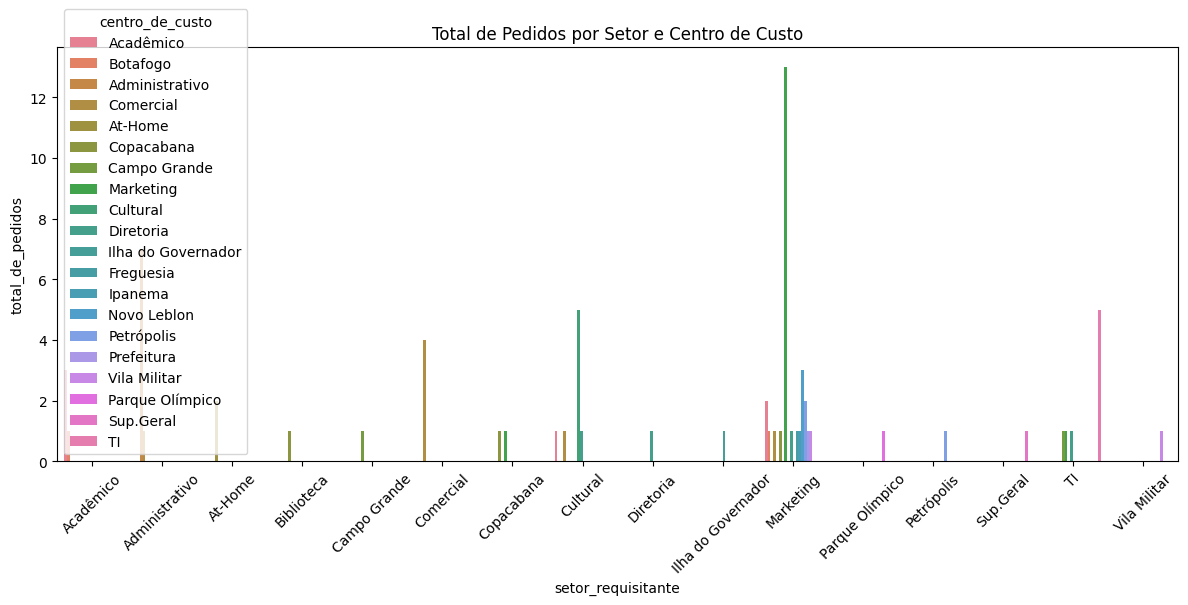

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(data=agrupado, x='setor_requisitante', y='total_de_pedidos', hue='centro_de_custo')
plt.title('Total de Pedidos por Setor e Centro de Custo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()